# HW14 - embeddings, FAISS, retrieval evaluation and mini-RAG

В этой работе я собрал компактный и воспроизводимый pipeline для поиска по небольшой локальной базе знаний по теме tabular machine learning.

Что есть в ноутбуке:
- подготовка небольшой тематической базы знаний;
- чанкинг документов;
- TF-IDF векторы и индекс `FAISS`;
- примеры retrieval и расчет `hit@k`, `recall@k`, `MRR@k`;
- один небольшой эксперимент по параметрам retrieval;
- обновление базы знаний и переиндексация;
- простой mini-RAG с возвратом источников.

Обязательные артефакты сохраняются в `homeworks/HW14/artifacts/`.

In [1]:
import importlib
import subprocess
import sys

required_packages = {
    "faiss": "faiss-cpu",
}

for module_name, package_name in required_packages.items():
    try:
        importlib.import_module(module_name)
    except ModuleNotFoundError:
        print(f"Installing missing package: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        importlib.invalidate_caches()
        importlib.import_module(module_name)
        print(f"Package {package_name} is ready.")

In [2]:
from pathlib import Path
import json
import platform
import random
import re
import sys

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 160)

SEED = 42
DEFAULT_TOP_K = 3
random.seed(SEED)
np.random.seed(SEED)

CURRENT_DIR = Path.cwd().resolve()
if CURRENT_DIR.name == "HW14" and (CURRENT_DIR / "artifacts").exists():
    HW_DIR = CURRENT_DIR
elif (CURRENT_DIR / "homeworks" / "HW14").exists():
    HW_DIR = CURRENT_DIR / "homeworks" / "HW14"
else:
    HW_DIR = CURRENT_DIR

ARTIFACTS_DIR = HW_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

env_info = pd.Series(
    {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "sklearn": sklearn.__version__,
        "faiss": faiss.__version__,
        "device": "CPU",
        "seed": SEED,
        "hw_dir": str(HW_DIR),
    }
)

env_info

python                                                            3.12.10
platform                                        Windows-11-10.0.26100-SP0
numpy                                                               2.3.5
pandas                                                              2.3.3
sklearn                                                             1.8.0
faiss                                                              1.13.2
device                                                                CPU
seed                                                                   42
hw_dir      C:\Users\Maken\Desktop\aie_goldobin_rsbo-01-24\homeworks\HW14
dtype: object

## 1. База знаний и первичный анализ

Базу знаний я сделал с нуля и посвятил ее теме tabular machine learning: разбиение данных, preprocessing, метрики, leakage, calibration и monitoring.

In [3]:
base_documents = [
    {
        "doc_id": "doc_01",
        "title": "Dataset split",
        "text": """Splitting data into train validation and test sets helps evaluate a model honestly. The train part is used to fit parameters, validation is used to compare hyperparameters and model variants, and test should stay untouched until the final check. If the test set is used too early, the whole workflow can silently overfit to it. For time series and grouped observations, the split must respect order or group boundaries, otherwise the quality estimate becomes too optimistic.""",
    },
    {
        "doc_id": "doc_02",
        "title": "Feature scaling",
        "text": """Scaling numeric features matters for logistic regression, regularized linear models, support vector machines, and distance based methods. When one feature is measured in thousands and another one is measured in fractions, optimization pays too much attention to the large scale. StandardScaler centers and standardizes columns, while MinMaxScaler maps values to a fixed range. A critical rule is to fit the scaler on the train split only and apply the fitted transformation to validation and test.""",
    },
    {
        "doc_id": "doc_03",
        "title": "Categorical features",
        "text": """Categorical variables should not be converted into arbitrary ordered integers unless a true order exists. For a small number of categories, one hot encoding is usually the safest baseline. When there are many rare values, it is often better to group them before encoding so the feature space does not explode. Encoders should also be fit on the train split only. Otherwise the feature engineering stage can leak information from held out data into the model pipeline.""",
    },
    {
        "doc_id": "doc_04",
        "title": "Missing values",
        "text": """Missing values should not be dropped automatically in every project because that can remove too much data and distort the sample. A common baseline is to add a missing indicator and choose a stable imputation strategy. Median imputation often works for numeric columns, while categorical fields can use a dedicated unknown category. If imputation statistics are computed on the full table before the split into train and test, the workflow introduces leakage. The same caution applies to any preprocessing step based on dataset wide statistics.""",
    },
    {
        "doc_id": "doc_05",
        "title": "Class imbalance",
        "text": """With severe class imbalance, accuracy can look strong even when the model ignores the minority class. In such settings it is better to inspect precision, recall, F1, PR AUC, and the confusion matrix. Additional tactics include class weights, undersampling, oversampling, and threshold adjustment. The right choice depends on the cost of mistakes. In many rare event problems, missing a positive case is much worse than triggering a few extra false alarms, so recall becomes a key business metric.""",
    },
    {
        "doc_id": "doc_06",
        "title": "Cross validation",
        "text": """Cross validation measures how stable a model is across several train validation splits instead of relying on one lucky partition. This is especially useful on small and medium sized datasets where one split can produce a noisy or optimistic estimate. Each fold repeats the same workflow on a different subset of rows. All preprocessing should live inside the same pipeline as the estimator so that scaling, imputation, and encoding are re fitted independently inside every fold rather than once on the full dataset.""",
    },
    {
        "doc_id": "doc_07",
        "title": "Classification metrics",
        "text": """Metric choice depends on the task rather than on convenience alone. Accuracy works best on balanced tasks with similar costs of false positives and false negatives, but imbalanced problems often require recall, precision, F1, ROC AUC, or PR AUC. A confusion matrix helps inspect trade offs directly instead of hiding them inside one number. A single aggregate metric is useful for fast model comparison, yet it rarely replaces case level analysis and domain specific business constraints.""",
    },
    {
        "doc_id": "doc_08",
        "title": "Regularization and overfitting",
        "text": """Regularization reduces overfitting when a model starts memorizing noise from the training data. In linear models, L1 can shrink some coefficients to zero, while L2 keeps weights smaller and smoother. The less data available and the more flexible the model, the more carefully regularization strength should be chosen. Its value must be selected through validation or cross validation rather than through repeated checks on the test set. Otherwise the test set stops being an honest final benchmark.""",
    },
    {
        "doc_id": "doc_09",
        "title": "Model interpretation",
        "text": """Interpretation is useful not only for presentations but also for debugging the dataset and feature space. Feature importance, linear coefficients, and local explanations can reveal surprising shortcuts learned by the model. If a system relies on fields that are unavailable at prediction time, that may indicate leakage or a broken training pipeline. Interpretation does not replace validation, but it can explain unstable metrics and point to suspicious correlations that deserve closer investigation before deployment.""",
    },
    {
        "doc_id": "doc_10",
        "title": "Pipelines and leakage prevention",
        "text": """A machine learning pipeline combines preprocessing and the estimator into one reproducible object. This is helpful not only for clean code but also for leakage prevention. When scalers, encoders, and imputers are fit inside the pipeline, they only see the train rows available at each training stage. If the full table is transformed before the split, feature statistics already contain information that should have stayed hidden. Pipelines are especially important during cross validation and hyperparameter tuning.""",
    },
    {
        "doc_id": "doc_11",
        "title": "Probability calibration",
        "text": """Some models rank observations well while still producing poorly calibrated probabilities. Calibration matters when a score must be interpreted as a real probability and used together with a decision threshold. In risk, medicine, and marketing, a predicted probability of 0.8 should roughly match eight positive outcomes out of ten similar cases. Good ROC AUC does not guarantee good calibration, so calibration quality should be checked separately when threshold based decisions matter.""",
    },
    {
        "doc_id": "doc_12",
        "title": "Error analysis",
        "text": """After summary metrics are computed, it is useful to inspect specific false positives and false negatives. Error analysis shows where the model fails most often and whether those failures cluster in certain segments of the data. This step frequently reveals weak labels, missing features, unstable data slices, or a poor decision threshold. It helps turn an abstract score into an action plan: collect data, engineer new features, revisit sampling, or adjust the operating point of the classifier.""",
    },
]

base_docs_df = pd.DataFrame(base_documents)
base_docs_df["n_words"] = base_docs_df["text"].str.split().str.len()
print(f"Number of source documents: {len(base_docs_df)}")
print(f"Total corpus size: {int(base_docs_df['n_words'].sum())} words")
base_docs_df[["doc_id", "title", "n_words"]]

Number of source documents: 12
Total corpus size: 925 words


,doc_id,title,n_words
0,doc_01,Dataset split,76
1,doc_02,Feature scaling,75
2,doc_03,Categorical features,77
3,doc_04,Missing values,85
4,doc_05,Class imbalance,78
5,doc_06,Cross validation,83
6,doc_07,Classification metrics,76
7,doc_08,Regularization and overfitting,77
8,doc_09,Model interpretation,74
9,doc_10,Pipelines and leakage prevention,76


In [4]:
base_docs_df[["doc_id", "title", "text"]].head(4)

,doc_id,title,text
0,doc_01,Dataset split,"Splitting data into train validation and test sets helps evaluate a model honestly. The train part is used to fit parameters, validation is used to compare ..."
1,doc_02,Feature scaling,"Scaling numeric features matters for logistic regression, regularized linear models, support vector machines, and distance based methods. When one feature i..."
2,doc_03,Categorical features,"Categorical variables should not be converted into arbitrary ordered integers unless a true order exists. For a small number of categories, one hot encoding..."
3,doc_04,Missing values,Missing values should not be dropped automatically in every project because that can remove too much data and distort the sample. A common baseline is to ad...


## 2. Чанкинг документов

Здесь использую простой и воспроизводимый чанкинг скользящим окном по словам. В базовой конфигурации беру `chunk_size=70` и `overlap=12`.

In [5]:
def clean_text(text: str) -> str:
    text = re.sub(r"\s+", " ", text.strip())
    return text


def chunk_document(text: str, chunk_size: int = 70, overlap: int = 12):
    words = clean_text(text).split()
    if not words:
        return []

    step = max(1, chunk_size - overlap)
    chunks = []
    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break
    return chunks


def build_chunks(documents, chunk_size: int = 70, overlap: int = 12):
    rows = []
    for doc in documents:
        doc_chunks = chunk_document(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for idx, chunk_text in enumerate(doc_chunks, start=1):
            rows.append(
                {
                    "chunk_id": f"{doc['doc_id']}_chunk_{idx:02d}",
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_index": idx,
                    "text": chunk_text,
                    "n_words": len(chunk_text.split()),
                }
            )
    return pd.DataFrame(rows)


baseline_chunk_size = 70
baseline_overlap = 12
baseline_chunks_df = build_chunks(base_documents, chunk_size=baseline_chunk_size, overlap=baseline_overlap)

print(f"Number of chunks: {len(baseline_chunks_df)}")
baseline_chunks_df.head(8)

Number of chunks: 24


,chunk_id,doc_id,title,chunk_index,text,n_words
0,doc_01_chunk_01,doc_01,Dataset split,1,"Splitting data into train validation and test sets helps evaluate a model honestly. The train part is used to fit parameters, validation is used to compare ...",70
1,doc_01_chunk_02,doc_01,Dataset split,2,"and grouped observations, the split must respect order or group boundaries, otherwise the quality estimate becomes too optimistic.",18
2,doc_02_chunk_01,doc_02,Feature scaling,1,"Scaling numeric features matters for logistic regression, regularized linear models, support vector machines, and distance based methods. When one feature i...",70
3,doc_02_chunk_02,doc_02,Feature scaling,2,fit the scaler on the train split only and apply the fitted transformation to validation and test.,17
4,doc_03_chunk_01,doc_03,Categorical features,1,"Categorical variables should not be converted into arbitrary ordered integers unless a true order exists. For a small number of categories, one hot encoding...",70
5,doc_03_chunk_02,doc_03,Categorical features,2,train split only. Otherwise the feature engineering stage can leak information from held out data into the model pipeline.,19
6,doc_04_chunk_01,doc_04,Missing values,1,Missing values should not be dropped automatically in every project because that can remove too much data and distort the sample. A common baseline is to ad...,70
7,doc_04_chunk_02,doc_04,Missing values,2,"the full table before the split into train and test, the workflow introduces leakage. The same caution applies to any preprocessing step based on dataset wi...",27


In [6]:
example_doc_id = "doc_10"
example_doc = next(doc for doc in base_documents if doc["doc_id"] == example_doc_id)
example_chunks = chunk_document(example_doc["text"], chunk_size=baseline_chunk_size, overlap=baseline_overlap)

pd.DataFrame(
    {
        "doc_id": example_doc_id,
        "chunk_index": range(1, len(example_chunks) + 1),
        "chunk_text": example_chunks,
    }
)

,doc_id,chunk_index,chunk_text
0,doc_10,1,A machine learning pipeline combines preprocessing and the estimator into one reproducible object. This is helpful not only for clean code but also for leak...
1,doc_10,2,already contain information that should have stayed hidden. Pipelines are especially important during cross validation and hyperparameter tuning.


## 3. Эмбеддинги, `FAISS` и retrieval

Для векторизации использую `TfidfVectorizer(ngram_range=(1, 2))`. Поиск выполняется через `FAISS IndexFlatIP` по L2-нормализованным векторам, что соответствует cosine similarity.

In [7]:
def build_retriever(documents, chunk_size: int = 70, overlap: int = 12):
    chunks_df = build_chunks(documents, chunk_size=chunk_size, overlap=overlap)
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
    chunk_matrix = vectorizer.fit_transform(chunks_df["text"])
    chunk_vectors = normalize(chunk_matrix, norm="l2", axis=1).astype(np.float32).toarray()

    index = faiss.IndexFlatIP(chunk_vectors.shape[1])
    index.add(chunk_vectors)

    return {
        "documents": documents,
        "chunks_df": chunks_df.reset_index(drop=True),
        "vectorizer": vectorizer,
        "chunk_vectors": chunk_vectors,
        "index": index,
        "chunk_size": chunk_size,
        "overlap": overlap,
    }


def retrieve_chunks(query, retriever, top_k: int = DEFAULT_TOP_K, search_k: int | None = None):
    chunks_df = retriever["chunks_df"]
    search_k = search_k or max(top_k * 5, top_k)
    search_k = min(search_k, len(chunks_df))

    query_matrix = retriever["vectorizer"].transform([query])
    if query_matrix.nnz == 0:
        return pd.DataFrame(columns=["rank", "doc_id", "title", "chunk_id", "score", "text"])

    query_vector = normalize(query_matrix, norm="l2", axis=1).astype(np.float32).toarray()
    scores, indices = retriever["index"].search(query_vector, search_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        row = chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "doc_id": row["doc_id"],
                "title": row["title"],
                "chunk_id": row["chunk_id"],
                "score": float(score),
                "text": row["text"],
            }
        )
    return pd.DataFrame(rows)


def retrieve_sources(query, retriever, top_k: int = DEFAULT_TOP_K):
    results = retrieve_chunks(query, retriever, top_k=top_k, search_k=max(12, top_k * 6))
    unique_sources = []
    for doc_id in results["doc_id"].tolist():
        if doc_id not in unique_sources:
            unique_sources.append(doc_id)
        if len(unique_sources) >= top_k:
            break
    return unique_sources


baseline_retriever = build_retriever(base_documents, chunk_size=baseline_chunk_size, overlap=baseline_overlap)
print(f"FAISS index size: {baseline_retriever['index'].ntotal}")

FAISS index size: 24


In [8]:
example_queries = [
    "why do we need a train validation test split",
    "how does a pipeline prevent leakage",
    "which metrics help with class imbalance",
    "when do we need probability calibration",
    "why inspect false positives and false negatives",
]

example_retrieval_frames = []
for query in example_queries:
    top_result = retrieve_chunks(query, baseline_retriever, top_k=3, search_k=8).head(3).copy()
    top_result.insert(0, "query", query)
    example_retrieval_frames.append(top_result)

pd.concat(example_retrieval_frames, ignore_index=True)

,query,rank,doc_id,title,chunk_id,score,text
0,why do we need a train validation test split,1,doc_01,Dataset split,doc_01_chunk_01,0.224714,"Splitting data into train validation and test sets helps evaluate a model honestly. The train part is used to fit parameters, validation is used to compare ..."
1,why do we need a train validation test split,2,doc_02,Feature scaling,doc_02_chunk_02,0.215565,fit the scaler on the train split only and apply the fitted transformation to validation and test.
2,why do we need a train validation test split,3,doc_06,Cross validation,doc_06_chunk_01,0.139811,Cross validation measures how stable a model is across several train validation splits instead of relying on one lucky partition. This is especially useful ...
3,how does a pipeline prevent leakage,1,doc_09,Model interpretation,doc_09_chunk_01,0.098874,"Interpretation is useful not only for presentations but also for debugging the dataset and feature space. Feature importance, linear coefficients, and local..."
4,how does a pipeline prevent leakage,2,doc_10,Pipelines and leakage prevention,doc_10_chunk_01,0.091772,A machine learning pipeline combines preprocessing and the estimator into one reproducible object. This is helpful not only for clean code but also for leak...
5,how does a pipeline prevent leakage,3,doc_06,Cross validation,doc_06_chunk_01,0.084001,Cross validation measures how stable a model is across several train validation splits instead of relying on one lucky partition. This is especially useful ...
6,which metrics help with class imbalance,1,doc_05,Class imbalance,doc_05_chunk_01,0.251065,"With severe class imbalance, accuracy can look strong even when the model ignores the minority class. In such settings it is better to inspect precision, re..."
7,which metrics help with class imbalance,2,doc_09,Model interpretation,doc_09_chunk_02,0.065656,it can explain unstable metrics and point to suspicious correlations that deserve closer investigation before deployment.
8,which metrics help with class imbalance,3,doc_07,Classification metrics,doc_07_chunk_01,0.029187,Metric choice depends on the task rather than on convenience alone. Accuracy works best on balanced tasks with similar costs of false positives and false ne...
9,when do we need probability calibration,1,doc_11,Probability calibration,doc_11_chunk_01,0.313953,Some models rank observations well while still producing poorly calibrated probabilities. Calibration matters when a score must be interpreted as a real pro...


## 4. Контрольные запросы и оценка retrieval

Ниже использую небольшой benchmark из 10 контрольных запросов. Релевантность проверяю на уровне `doc_id`.

In [9]:
control_queries = [
    {"query": "why split data into train validation and test", "expected_sources": ["doc_01"]},
    {"query": "why should a scaler be fit only on the train split", "expected_sources": ["doc_02", "doc_10"]},
    {"query": "how to encode categorical variables without fake order", "expected_sources": ["doc_03"]},
    {"query": "how to handle missing values without leakage", "expected_sources": ["doc_04", "doc_10"]},
    {"query": "what to do with severe class imbalance", "expected_sources": ["doc_05"]},
    {"query": "why use cross validation on a small dataset", "expected_sources": ["doc_06"]},
    {"query": "which metrics matter when accuracy is misleading", "expected_sources": ["doc_05", "doc_07"]},
    {"query": "how does regularization reduce overfitting", "expected_sources": ["doc_08"]},
    {"query": "why are pipelines important during cross validation", "expected_sources": ["doc_10", "doc_06"]},
    {"query": "why inspect false positives and false negatives after metrics", "expected_sources": ["doc_12", "doc_07"]},
]


def evaluate_queries(retriever, queries, top_k: int = DEFAULT_TOP_K):
    rows = []
    for item in queries:
        expected_sources = item["expected_sources"]
        retrieved_sources = retrieve_sources(item["query"], retriever, top_k=top_k)
        rank = next((idx for idx, source in enumerate(retrieved_sources, start=1) if source in expected_sources), None)
        hit_at_k = int(rank is not None)
        recall_at_k = sum(source in expected_sources for source in retrieved_sources) / len(expected_sources)
        mrr_at_k = 0.0 if rank is None else 1.0 / rank
        rows.append(
            {
                "query": item["query"],
                "expected_source": " | ".join(expected_sources),
                "retrieved_sources": " | ".join(retrieved_sources),
                "hit_at_k": hit_at_k,
                "recall_at_k": round(recall_at_k, 4),
                "rank_of_first_relevant": rank,
                "mrr_at_k": round(mrr_at_k, 4),
            }
        )
    eval_df = pd.DataFrame(rows)
    summary = {
        "hit_at_k": float(eval_df["hit_at_k"].mean()),
        "recall_at_k": float(eval_df["recall_at_k"].mean()),
        "mrr_at_k": float(eval_df["mrr_at_k"].mean()),
    }
    return eval_df, summary


retrieval_eval_df, retrieval_summary = evaluate_queries(baseline_retriever, control_queries, top_k=DEFAULT_TOP_K)
retrieval_eval_path = ARTIFACTS_DIR / "retrieval_eval.csv"
retrieval_eval_df.to_csv(retrieval_eval_path, index=False, encoding="utf-8-sig")

pd.Series(retrieval_summary).round(4)

hit_at_k       1.00
recall_at_k    0.90
mrr_at_k       0.95
dtype: float64

In [10]:
retrieval_eval_df

,query,expected_source,retrieved_sources,hit_at_k,recall_at_k,rank_of_first_relevant,mrr_at_k
0,why split data into train validation and test,doc_01,doc_01 | doc_02 | doc_03,1,1.0,1,1.0
1,why should a scaler be fit only on the train split,doc_02 | doc_10,doc_02 | doc_03 | doc_10,1,1.0,1,1.0
2,how to encode categorical variables without fake order,doc_03,doc_03 | doc_01 | doc_04,1,1.0,1,1.0
3,how to handle missing values without leakage,doc_04 | doc_10,doc_04 | doc_02 | doc_06,1,0.5,1,1.0
4,what to do with severe class imbalance,doc_05,doc_05 | doc_02 | doc_01,1,1.0,1,1.0
5,why use cross validation on a small dataset,doc_06,doc_06 | doc_10 | doc_08,1,1.0,1,1.0
6,which metrics matter when accuracy is misleading,doc_05 | doc_07,doc_11 | doc_05 | doc_09,1,0.5,2,0.5
7,how does regularization reduce overfitting,doc_08,doc_08 | doc_06 | doc_03,1,1.0,1,1.0
8,why are pipelines important during cross validation,doc_10 | doc_06,doc_10 | doc_06 | doc_08,1,1.0,1,1.0
9,why inspect false positives and false negatives after metrics,doc_12 | doc_07,doc_12 | doc_07 | doc_05,1,1.0,1,1.0


## 5. Небольшой эксперимент с параметрами retrieval

В качестве короткого эксперимента сравниваю два значения `chunk_size`: `35` и `70` при одинаковом `overlap=12`.

In [11]:
experiment_rows = []
for chunk_size in [35, 70]:
    retriever = build_retriever(base_documents, chunk_size=chunk_size, overlap=baseline_overlap)
    _, summary = evaluate_queries(retriever, control_queries, top_k=DEFAULT_TOP_K)
    experiment_rows.append(
        {
            "chunk_size": chunk_size,
            "overlap": baseline_overlap,
            "n_chunks": len(retriever["chunks_df"]),
            "hit_at_k": round(summary["hit_at_k"], 4),
            "recall_at_k": round(summary["recall_at_k"], 4),
            "mrr_at_k": round(summary["mrr_at_k"], 4),
        }
    )

experiment_df = pd.DataFrame(experiment_rows)
experiment_df

,chunk_size,overlap,n_chunks,hit_at_k,recall_at_k,mrr_at_k
0,35,12,38,1.0,0.9,0.90
1,70,12,24,1.0,0.9,0.95


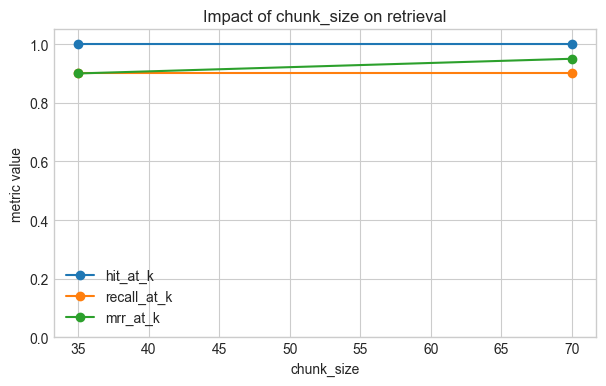

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
for metric in ["hit_at_k", "recall_at_k", "mrr_at_k"]:
    ax.plot(experiment_df["chunk_size"], experiment_df[metric], marker="o", label=metric)
ax.set_title("Impact of chunk_size on retrieval")
ax.set_xlabel("chunk_size")
ax.set_ylabel("metric value")
ax.set_ylim(0, 1.05)
ax.legend()
plt.show()

## 6. Обновление базы знаний и переиндексация

На этом шаге добавляю три новых документа: про threshold tuning, monitoring data drift и checklist для target leakage.

In [13]:
new_documents = [
    {
        "doc_id": "doc_13",
        "title": "Threshold tuning",
        "text": """After a probabilistic classifier is trained, the default decision threshold is often not the best operating point. When the costs of false positives and false negatives differ, the best threshold changes as well. It is practical to tune the threshold on a validation split using business metrics, the confusion matrix, or the precision recall curve. In medical screening recall may dominate, while in fraud prevention too many false alarms can also be expensive. Good calibration helps, but threshold tuning is still a separate step.""",
    },
    {
        "doc_id": "doc_14",
        "title": "Data drift monitoring",
        "text": """After deployment, it is important to monitor data drift and shifts in target behavior. If feature distributions in production move away from the training sample, model quality can degrade even when the code is correct. Typical signals include feature summary statistics, missing value rates, prediction scores, delayed labels, and segment level stability. Drift does not always mean the model must be replaced immediately, but it should trigger a review of data quality, performance, and possible retraining plans.""",
    },
    {
        "doc_id": "doc_15",
        "title": "Target leakage checklist",
        "text": """A target leakage review is useful before the first serious model training run. Helpful questions include whether a feature is available at prediction time, whether it is computed after the target event, whether an aggregate uses future information, and whether any manual fields were created after a human decision was already made. Leakage often looks like a suspiciously powerful feature and leads to unrealistically good metrics. A checklist, feature interpretation, and a strict pipeline together make leakage easier to catch.""",
    },
]

updated_documents = base_documents + new_documents
updated_retriever = build_retriever(updated_documents, chunk_size=baseline_chunk_size, overlap=baseline_overlap)
print(f"Documents after update: {len(updated_documents)}")
print(f"Chunks after update: {len(updated_retriever['chunks_df'])}")

Documents after update: 15
Chunks after update: 30


In [14]:
update_queries = [
    {"query": "how to choose a threshold when error costs differ", "expected_sources": ["doc_13"]},
    {"query": "how to detect data drift after deployment", "expected_sources": ["doc_14"]},
    {"query": "which questions help detect target leakage", "expected_sources": ["doc_15"]},
    {"query": "why is the default probability threshold not always optimal", "expected_sources": ["doc_13", "doc_11"]},
]

before_rows = []
for item in update_queries:
    before_sources = retrieve_sources(item["query"], baseline_retriever, top_k=DEFAULT_TOP_K)
    after_sources = retrieve_sources(item["query"], updated_retriever, top_k=DEFAULT_TOP_K)
    before_hit = int(any(source in item["expected_sources"] for source in before_sources))
    after_hit = int(any(source in item["expected_sources"] for source in after_sources))
    before_rows.append(
        {
            "query": item["query"],
            "before_retrieved_sources": " | ".join(before_sources),
            "after_retrieved_sources": " | ".join(after_sources),
            "changed": before_sources != after_sources,
            "before_hit_at_k": before_hit,
            "after_hit_at_k": after_hit,
            "expected_source": " | ".join(item["expected_sources"]),
        }
    )

before_after_df = pd.DataFrame(before_rows)
before_after_path = ARTIFACTS_DIR / "retrieval_before_after_update.csv"
before_after_df.to_csv(before_after_path, index=False, encoding="utf-8-sig")

before_after_df

,query,before_retrieved_sources,after_retrieved_sources,changed,before_hit_at_k,after_hit_at_k,expected_source
0,how to choose a threshold when error costs differ,doc_11 | doc_12 | doc_04,doc_13 | doc_11 | doc_12,True,0,1,doc_13
1,how to detect data drift after deployment,doc_09 | doc_12 | doc_01,doc_14 | doc_09 | doc_12,True,0,1,doc_14
2,which questions help detect target leakage,doc_04 | doc_10 | doc_09,doc_15 | doc_04 | doc_14,True,0,1,doc_15
3,why is the default probability threshold not always optimal,doc_11 | doc_03 | doc_05,doc_13 | doc_11 | doc_14,True,1,1,doc_13 | doc_11


## 7. Mini-RAG

В качестве answer generator использую простой extractive baseline: retrieval находит top-k чанков, после чего из найденного контекста выбираются наиболее релевантные предложения.

In [15]:
def split_sentences(text: str):
    parts = re.split(r"(?<=[.!?])\s+", clean_text(text))
    return [part.strip() for part in parts if part.strip()]


def answer_question(question: str, retriever, top_k: int = DEFAULT_TOP_K, max_sentences: int = 2):
    retrieved = retrieve_chunks(question, retriever, top_k=top_k, search_k=max(12, top_k * 6)).head(top_k)
    if retrieved.empty:
        return {
            "question": question,
            "answer": "No supporting context was found in the knowledge base.",
            "retrieved_sources": "",
        }

    sentences = []
    for _, row in retrieved.iterrows():
        for sentence in split_sentences(row["text"]):
            sentences.append({"doc_id": row["doc_id"], "sentence": sentence})

    sentence_texts = [item["sentence"] for item in sentences]
    sentence_vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    sentence_matrix = sentence_vectorizer.fit_transform(sentence_texts + [question])
    sentence_vectors = normalize(sentence_matrix, norm="l2", axis=1)
    query_vector = sentence_vectors[-1]
    sentence_scores = (sentence_vectors[:-1] @ query_vector.T).toarray().ravel()

    best_idx = np.argsort(sentence_scores)[::-1][:max_sentences]
    selected_sentences = [sentence_texts[idx] for idx in best_idx if sentence_scores[idx] > 0]
    if not selected_sentences:
        answer = "The retrieved context is too weak to support a confident answer."
    else:
        answer = " ".join(selected_sentences)

    retrieved_sources = []
    for doc_id in retrieved["doc_id"].tolist():
        if doc_id not in retrieved_sources:
            retrieved_sources.append(doc_id)

    return {
        "question": question,
        "answer": answer,
        "retrieved_sources": " | ".join(retrieved_sources),
    }


rag_questions = [
    "Why does a pipeline help prevent leakage?",
    "When is cross validation especially useful?",
    "Why calibrate predicted probabilities?",
    "How should data drift be monitored after deployment?",
    "Why does threshold tuning affect business outcomes?",
]

rag_examples_df = pd.DataFrame([answer_question(question, updated_retriever) for question in rag_questions])
rag_examples_path = ARTIFACTS_DIR / "rag_examples.csv"
rag_examples_df.to_csv(rag_examples_path, index=False, encoding="utf-8-sig")
rag_examples_df

,question,answer,retrieved_sources
0,Why does a pipeline help prevent leakage?,"A checklist, feature interpretation, and a strict pipeline together make leakage easier to catch. If a system relies on fields that are unavailable at predi...",doc_15 | doc_09 | doc_10
1,When is cross validation especially useful?,Pipelines are especially important during cross validation and hyperparameter tuning. This is especially useful on small and medium sized datasets where one...,doc_10 | doc_06 | doc_08
2,Why calibrate predicted probabilities?,"Some models rank observations well while still producing poorly calibrated probabilities. In risk, medicine, and marketing, a predicted probability of 0.8 s...",doc_11 | doc_09
3,How should data drift be monitored after deployment?,"After deployment, it is important to monitor data drift and shifts in target behavior. Drift does not always mean the model must be replaced immediately, bu...",doc_14 | doc_09
4,Why does threshold tuning affect business outcomes?,"Good calibration helps, but threshold tuning is still a separate step. Good ROC AUC does not guarantee good calibration, so calibration quality should be ch...",doc_13 | doc_11


## 8. Краткий анализ ошибок

Эти пограничные примеры показывают, что даже аккуратный retrieval pipeline и простой mini-RAG все равно имеют заметные ограничения.

In [16]:
edge_questions = [
    "How can I make the model simply better?",
    "Can high accuracy be trusted with a rare positive class?",
    "When is it safe to ignore leakage?",
]

edge_case_rows = []
for question in edge_questions:
    result = answer_question(question, updated_retriever)
    edge_case_rows.append(result)

edge_cases_df = pd.DataFrame(edge_case_rows)
edge_cases_df

,question,answer,retrieved_sources
0,How can I make the model simply better?,"Otherwise the feature engineering stage can leak information from held out data into the model pipeline. With severe class imbalance, accuracy can look stro...",doc_03 | doc_05 | doc_08
1,Can high accuracy be trusted with a rare positive class?,"With severe class imbalance, accuracy can look strong even when the model ignores the minority class. In many rare event problems, missing a positive case i...",doc_05 | doc_11 | doc_03
2,When is it safe to ignore leakage?,"When one feature is measured in thousands and another one is measured in fractions, optimization pays too much attention to the large scale. A target leakag...",doc_15 | doc_02


In [17]:
pd.Series(
    {
        "retrieval_eval": retrieval_eval_path.name,
        "before_after": before_after_path.name,
        "rag_examples": rag_examples_path.name,
    }
)

retrieval_eval                   retrieval_eval.csv
before_after      retrieval_before_after_update.csv
rag_examples                       rag_examples.csv
dtype: object